In [13]:
import numpy as np
import matplotlib.pyplot as plt
from ngn import make_grid, make_centers, ngn_density, threshold
from rbf import rbf_density, normalize
from visualize import plot_density, check_connectivity

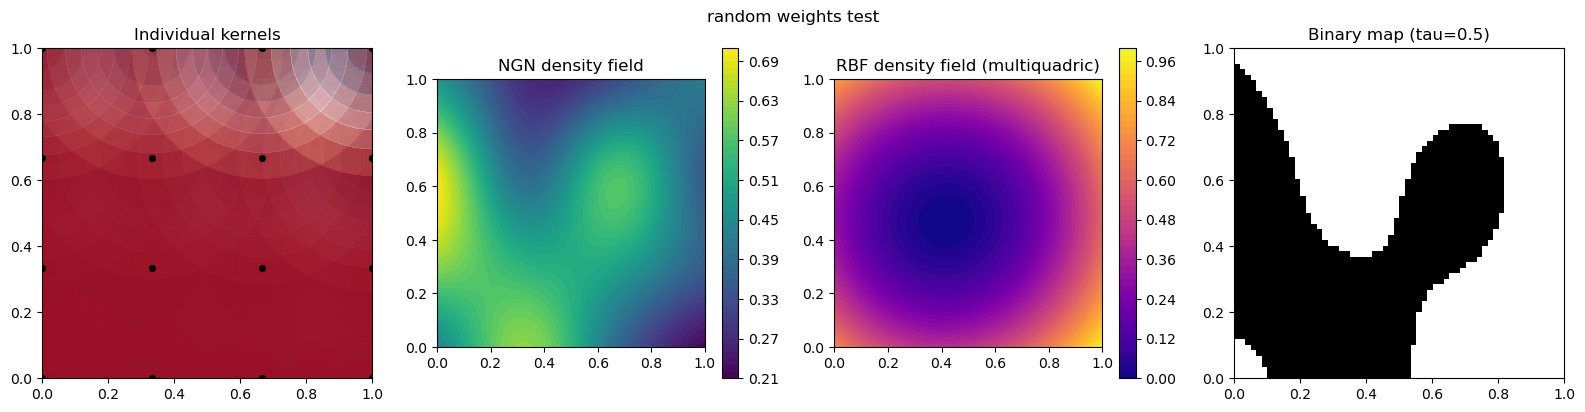

In [61]:
np.random.seed(34)
w = np.random.rand(N)
XX, YY = make_grid(60)
centers = make_centers(4)
N = len(centers)
weights = np.random.rand(N)

plot_density(weights, centers, sigma=0.2, tau=0.5, title='random weights test')

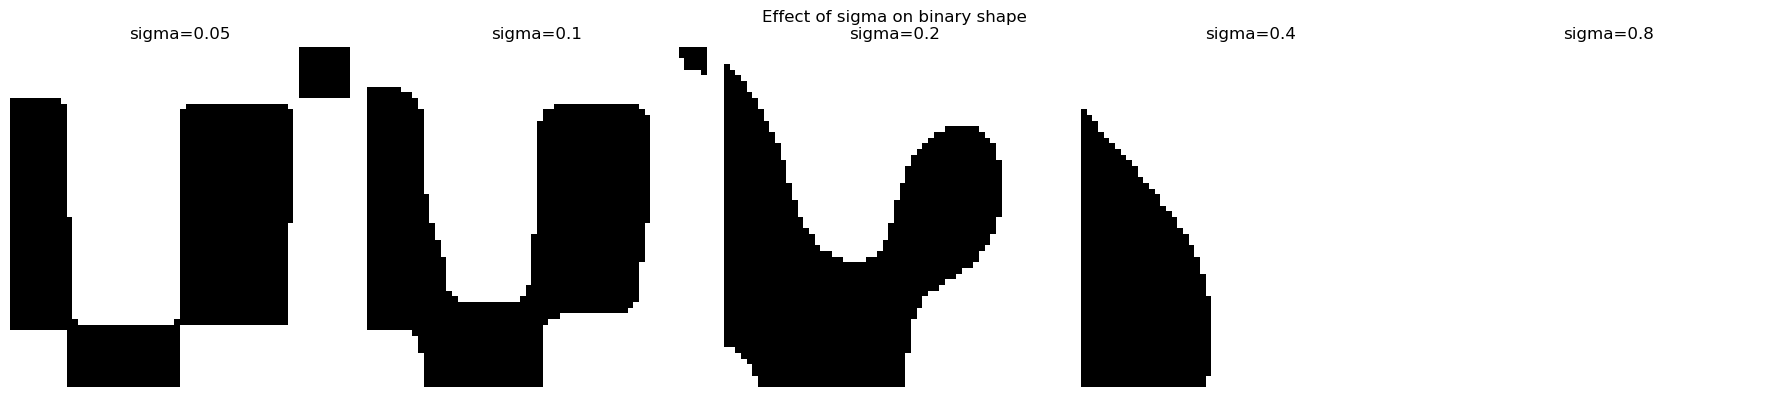

In [60]:
np.random.seed(34)
w = np.random.rand(N)
sigmas = [0.05, 0.1, 0.2, 0.4, 0.8]
fig, axes = plt.subplots(1, len(sigmas), figsize=(18, 4))

w = np.random.rand(N)

for i, sig in enumerate(sigmas):
    rho = ngn_density(w, XX, YY, centers, sigma=sig)
    B = threshold(rho, tau=0.5)
    axes[i].imshow(B, cmap='gray_r', origin='lower')
    axes[i].set_title(f'sigma={sig}')
    axes[i].axis('off')

plt.suptitle('Effect of sigma on binary shape')
plt.tight_layout()
plt.show()

Observation - Sigma Sweep
sigma controls how far each kernel's influence spreads across the domain. If too small: kernels act independently producing disconnected fragments, if too large: they all blend together losing any meaningful shape detail. For a 4x4 grid, sigma=0.2 gives the best trade-off — kernels overlap just enough to form one connected iron region.

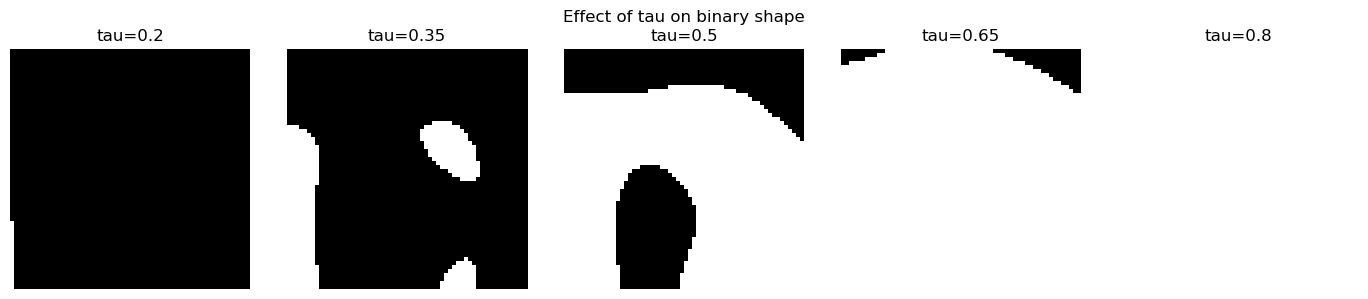

In [59]:
np.random.seed(34)
w = np.random.rand(N)
taus = [0.2, 0.35, 0.5, 0.65, 0.8]
fig, axes = plt.subplots(1, len(taus), figsize=(14, 3))

# keeping sigma fixed now, only changing the threshold
for i, tau in enumerate(taus):
    rho = ngn_density(w, XX, YY, centers, sigma=0.2)
    B = threshold(rho, tau=tau)
    axes[i].imshow(B, cmap='gray_r', origin='lower')
    axes[i].set_title(f'tau={tau}')
    axes[i].axis('off')

plt.suptitle('Effect of tau on binary shape')
plt.tight_layout()
plt.show()

Observations - Tau Sweep
Threshold controls iron volume — lower tau means more iron, higher means less.
Connectivity breaks between tau=0.35 and tau=0.5, and the useful range is bounded
by the actual min/max of the density field, not a fixed universal value.

In [63]:
rho = ngn_density(w, XX, YY, centers, sigma=0.2)

for tau in taus:
    B = threshold(rho, tau=tau)
    is_connected, n_components = check_connectivity(B)
    print(f'tau={tau}  |  connected: {is_connected}  |  components: {n_components}')

tau=0.2  |  connected: True  |  components: 1
tau=0.35  |  connected: True  |  components: 1
tau=0.5  |  connected: False  |  components: 2
tau=0.65  |  connected: False  |  components: 2
tau=0.8  |  connected: True  |  components: 0


In [65]:
rho = ngn_density(w, XX, YY, centers, sigma=0.2)
print(f'min: {rho.min():.3f}')
print(f'max: {rho.max():.3f}')
print(f'mean: {rho.mean():.3f}')

min: 0.189
max: 0.761
mean: 0.456


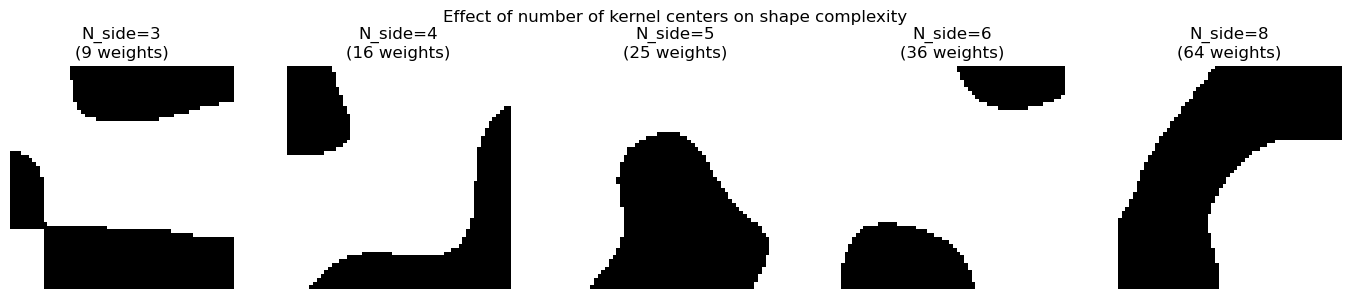

In [66]:
n_sides = [3, 4, 5, 6, 8]
fig, axes = plt.subplots(1, len(n_sides), figsize=(14, 3))

for i, n_side in enumerate(n_sides):
    centers_n = make_centers(n_side)
    N_n = len(centers_n)
    np.random.seed(42)
    w_n = np.random.rand(N_n)
    rho = ngn_density(w_n, XX, YY, centers_n, sigma=0.2)
    B = threshold(rho, tau=0.5)
    axes[i].imshow(B, cmap='gray_r', origin='lower')
    axes[i].set_title(f'N_side={n_side}\n({N_n} weights)')
    axes[i].axis('off')

plt.suptitle('Effect of number of kernel centers on shape complexity')
plt.tight_layout()
plt.show()

Observation - N_side Sweep
More centers means richer shapes but harder GA search. 
N_side=3 under-covers the domain producing fragments, N_side=8 gives fine detail but 64 weights is expensive. N_side=5 balances shape complexity and GA tractability with 25 weights.

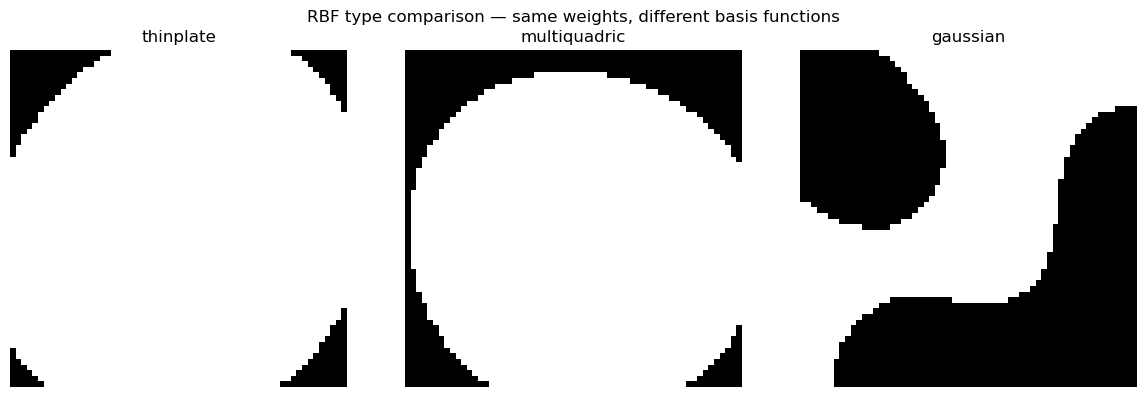

In [67]:
rbf_types = ['thinplate', 'multiquadric', 'gaussian']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

np.random.seed(42)
centers_fixed = make_centers(4)
w_fixed = np.random.rand(len(centers_fixed))

for i, rbf_type in enumerate(rbf_types):
    rho = rbf_density(w_fixed, XX, YY, centers_fixed, rbf_type=rbf_type)
    rho_n = normalize(rho)
    B = threshold(rho_n, tau=0.5)
    axes[i].imshow(B, cmap='gray_r', origin='lower')
    axes[i].set_title(rbf_type)
    axes[i].axis('off')

plt.suptitle('RBF type comparison — same weights, different basis functions')
plt.tight_layout()
plt.show()

Observation - RBF Comparison
All three plots use identical weights but produce completely different shapes — the basis function type alone changes the geometry. Thinplate and multiquadric spread each kernel's influence across the whole domain so the shapes come out smooth and symmetric.
Gaussian keeps influence local to each center, which creates sharper boundaries and disconnected regions.